## Section 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Section 2: Load Trained Model and Tokenizer

In [ ]:
# Load the trained IndoBERT model
model_path = './model/indobert_model'
tokenizer_path = './model/indobert_tokenizer'

print("Loading trained model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()  # Set to evaluation mode

print(f"Model loaded from: {model_path}")
print(f"Tokenizer loaded from: {tokenizer_path}")
print(f"Model is on device: {device}")
print(f"Number of labels: {model.config.num_labels}")

Loading trained model and tokenizer...
Model loaded from: ./model/indobert_model
Tokenizer loaded from: ./model/indobert_tokenizer
Model is on device: cuda
Number of labels: 3


## Section 3: Create Prediction Function

In [ ]:
# Define label mapping
label_mapping = {
    0: 'Positive',
    1: 'Neutral',
    2: 'Negative'
}

def predict_sentiment(text, model, tokenizer, device):
    """
    Predict sentiment for a single comment.

    Args:
        text: String containing the comment
        model: Trained IndoBERT model
        tokenizer: IndoBERT tokenizer
        device: torch device (cuda or cpu)

    Returns:
        Dictionary with prediction label and confidence score
    """
    # Prepare text
    text = str(text) if pd.notna(text) else ""

    # Tokenize
    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_label = torch.argmax(logits, dim=1).item()
        confidence = probabilities[0][predicted_label].item()

    return {
        'label': label_mapping.get(predicted_label, f'Class {predicted_label}'),
        'confidence': confidence
    }

print("Prediction function created successfully!")

Prediction function created successfully!


## Section 4: Test on Sample Comments

In [ ]:
# Test on sample comments
test_comments = [
    "Sangat bagus dan luar biasa!",  # Very good and amazing
    "Ini buruk sekali",  # This is very bad
    "Biasa saja tidak istimewa",  # Just okay, nothing special
    "Mantap banget, suka banget",  # Very cool, really like it
    "Mengecewakan dan tidak berguna"  # Disappointing and useless
]

print("Testing sentiment prediction on sample comments:\n")
print("="*80)

for comment in test_comments:
    result = predict_sentiment(comment, model, tokenizer, device)
    print(f"Comment: {comment}")
    print(f"Sentiment: {result['label']} (Confidence: {result['confidence']:.4f})")
    print("-"*80)

Testing sentiment prediction on sample comments:

Comment: Sangat bagus dan luar biasa!
Sentiment: Positive (Confidence: 0.9882)
--------------------------------------------------------------------------------
Comment: Ini buruk sekali
Sentiment: Negative (Confidence: 0.9957)
--------------------------------------------------------------------------------
Comment: Biasa saja tidak istimewa
Sentiment: Negative (Confidence: 0.6045)
--------------------------------------------------------------------------------
Comment: Mantap banget, suka banget
Sentiment: Positive (Confidence: 0.9891)
--------------------------------------------------------------------------------
Comment: Mengecewakan dan tidak berguna
Sentiment: Negative (Confidence: 0.9542)
--------------------------------------------------------------------------------


## Section 5: Load and Predict on Dataset

In [ ]:
# Load the cleaned comments dataset
df = pd.read_csv('./data/cleaned_comment_yt.csv')

print(f"Loaded dataset with {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 comments:")
for i, comment in enumerate(df['cleaned_comments'].head(3), 1):
    print(f"{i}. {comment[:100]}...")

Loaded dataset with 21969 comments
Columns: ['comments', 'cleaned_comments']

First 3 comments:
1. lama makin sini hukum makin jelasuu ampas aset kenapa tele tir hidup indonesia...
2. bnr padahal pilih dari suara rakyat...
3. houwwwwwakan anyak rakyat yang penjaradan makin besar pula siksa dan azab presiden dan wakil untyk a...


## Section 6: Predict Sentiment for All Comments

In [ ]:
# Predict sentiment for all comments
print(f"Predicting sentiment for {len(df)} comments...")
print("This may take a few minutes depending on dataset size...\n")

predictions = []
confidences = []

for i, comment in enumerate(df['cleaned_comments']):
    result = predict_sentiment(comment, model, tokenizer, device)
    predictions.append(result['label'])
    confidences.append(result['confidence'])

    # Progress indicator
    if (i + 1) % 1000 == 0:
        print(f"Completed: {i + 1}/{len(df)} comments")

print(f"\nCompleted! Processed all {len(df)} comments.")

# Add predictions to dataframe
df['predicted_sentiment'] = predictions
df['confidence'] = confidences

print(f"\nFirst 5 predictions:")
print(df[['cleaned_comments', 'predicted_sentiment', 'confidence']].head())

Predicting sentiment for 21969 comments...
This may take a few minutes depending on dataset size...

Completed: 1000/21969 comments
Completed: 2000/21969 comments
Completed: 3000/21969 comments
Completed: 4000/21969 comments
Completed: 5000/21969 comments
Completed: 6000/21969 comments
Completed: 7000/21969 comments
Completed: 8000/21969 comments
Completed: 9000/21969 comments
Completed: 10000/21969 comments
Completed: 11000/21969 comments
Completed: 12000/21969 comments
Completed: 13000/21969 comments
Completed: 14000/21969 comments
Completed: 15000/21969 comments
Completed: 16000/21969 comments
Completed: 17000/21969 comments
Completed: 18000/21969 comments
Completed: 19000/21969 comments
Completed: 20000/21969 comments
Completed: 21000/21969 comments

Completed! Processed all 21969 comments.

First 5 predictions:
                                    cleaned_comments predicted_sentiment  \
0  lama makin sini hukum makin jelasuu ampas aset...            Negative   
1                bnr

## Section 7: Analyze Sentiment Distribution

In [ ]:
# Analyze sentiment distribution
sentiment_counts = df['predicted_sentiment'].value_counts()
sentiment_percentages = df['predicted_sentiment'].value_counts(normalize=True) * 100

print("\nSentiment Distribution:")
print("="*60)
for sentiment in ['Negative', 'Neutral', 'Positive']:
    if sentiment in sentiment_counts.index:
        count = sentiment_counts[sentiment]
        percentage = sentiment_percentages[sentiment]
        print(f"{sentiment:10s}: {count:6d} comments ({percentage:6.2f}%)")

print("="*60)
print(f"{'Total':10s}: {len(df):6d} comments (100.00%)")

# Average confidence by sentiment
print(f"\nAverage Confidence by Sentiment:")
print("="*60)
for sentiment in ['Negative', 'Neutral', 'Positive']:
    avg_conf = df[df['predicted_sentiment'] == sentiment]['confidence'].mean()
    print(f"{sentiment:10s}: {avg_conf:.4f}")


Sentiment Distribution:
Negative  :  15869 comments ( 72.23%)
Neutral   :   2683 comments ( 12.21%)
Positive  :   3417 comments ( 15.55%)
Total     :  21969 comments (100.00%)

Average Confidence by Sentiment:
Negative  : 0.9397
Neutral   : 0.8009
Positive  : 0.8621


## Section 8: Visualize Results

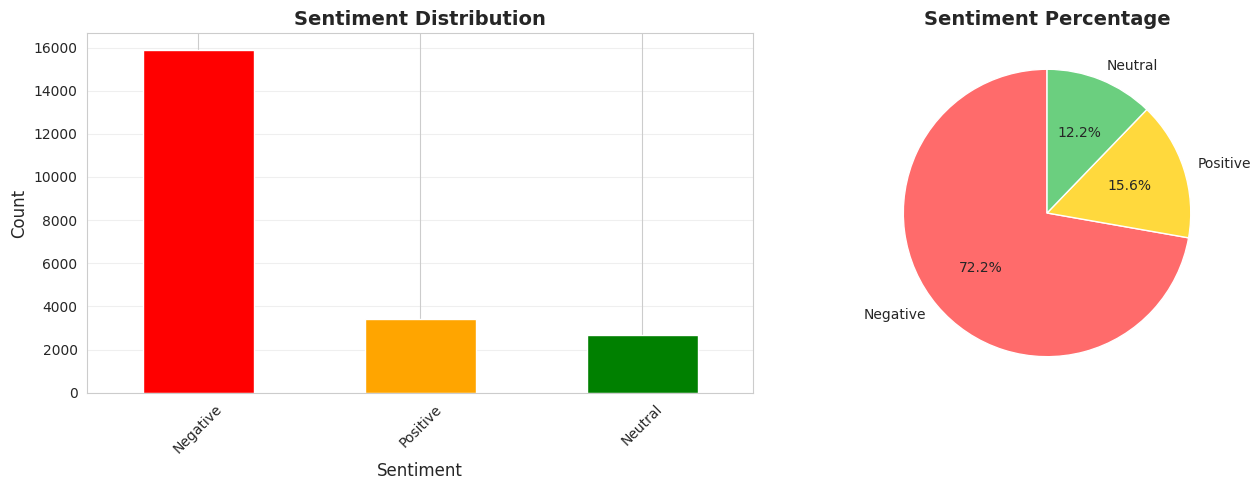

Visualization complete!


In [ ]:
import matplotlib.pyplot as plt

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of sentiment distribution
sentiment_counts.plot(kind='bar', ax=axes[0], color=['red', 'orange', 'green'])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart of sentiment percentages
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']
axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization complete!")

## Section 9: Save Predictions

In [ ]:
# Save predictions to CSV
output_path = './data/indobert_sentiment_predictions.csv'
df.to_csv(output_path, index=False)

print(f"Predictions saved to: {output_path}")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Show some example predictions
print(f"\nSample Predictions:")
print(df[['comments', 'predicted_sentiment', 'confidence']].head(10).to_string())

Predictions saved to: ./data/indobert_sentiment_predictions.csv

Dataset shape: (21969, 4)
Columns: ['comments', 'cleaned_comments', 'predicted_sentiment', 'confidence']

Sample Predictions:
                                                                                                                                                                                                                                                  comments predicted_sentiment  confidence
0                                                                                                                                      Makin lama makin ke sini hukum semakin ga jelas...uu perampasan aset kenapa bertele tele...miris hidup di indonesia            Negative    0.996704
1                                                                                                                                                                                                              Gila bnr padahal di pilih dari suara

## Section: Data Visualization

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


### 1. Sentiment Distribution

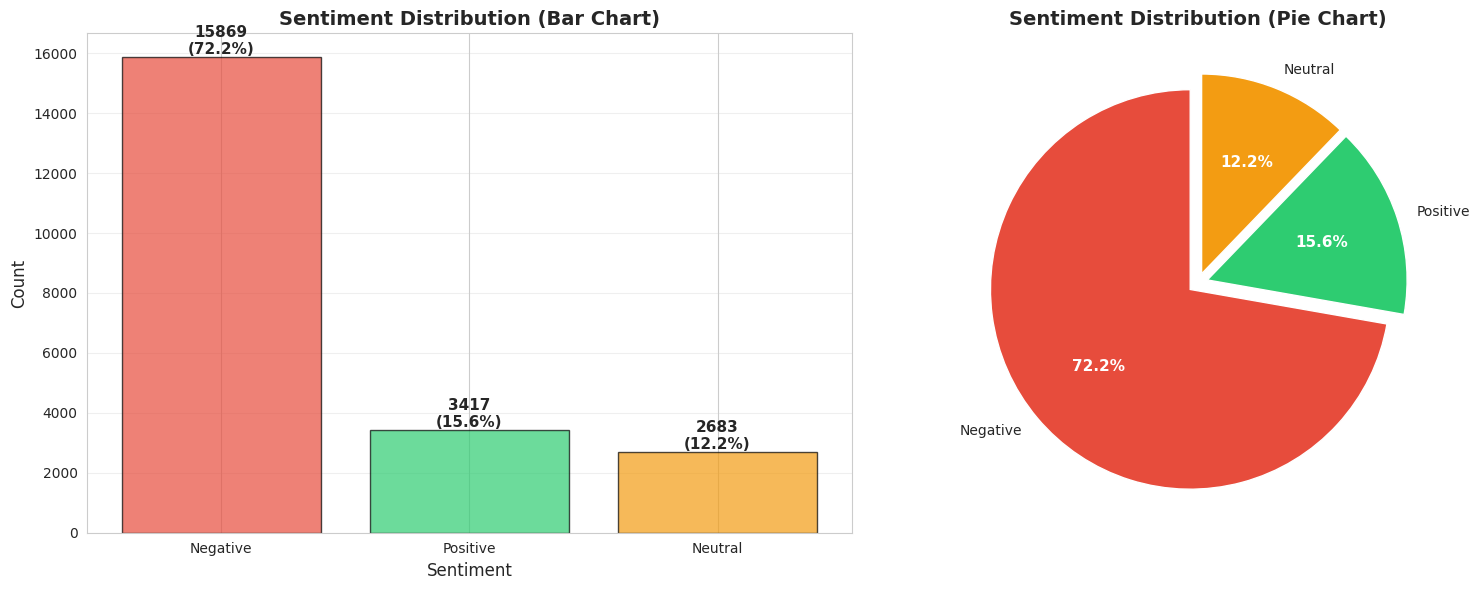


Sentiment Distribution:
Negative: 15869 (72.23%)
Positive: 3417 (15.55%)
Neutral: 2683 (12.21%)


In [ ]:
# Sentiment distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
sentiment_counts = df['predicted_sentiment'].value_counts()
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bar_colors = [colors[sent] for sent in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Sentiment Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (sent, count) in enumerate(sentiment_counts.items()):
    axes[0].text(i, count, f'{count}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
pie_colors = [colors[sent] for sent in sentiment_counts.index]
wedges, texts, autotexts = axes[1].pie(sentiment_counts.values,
                                        labels=sentiment_counts.index,
                                        colors=pie_colors,
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        explode=[0.05] * len(sentiment_counts))
axes[1].set_title('Sentiment Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.tight_layout()
plt.show()

print(f"\nSentiment Distribution:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count} ({count/len(df)*100:.2f}%)")

### 2. Confidence Score Distribution

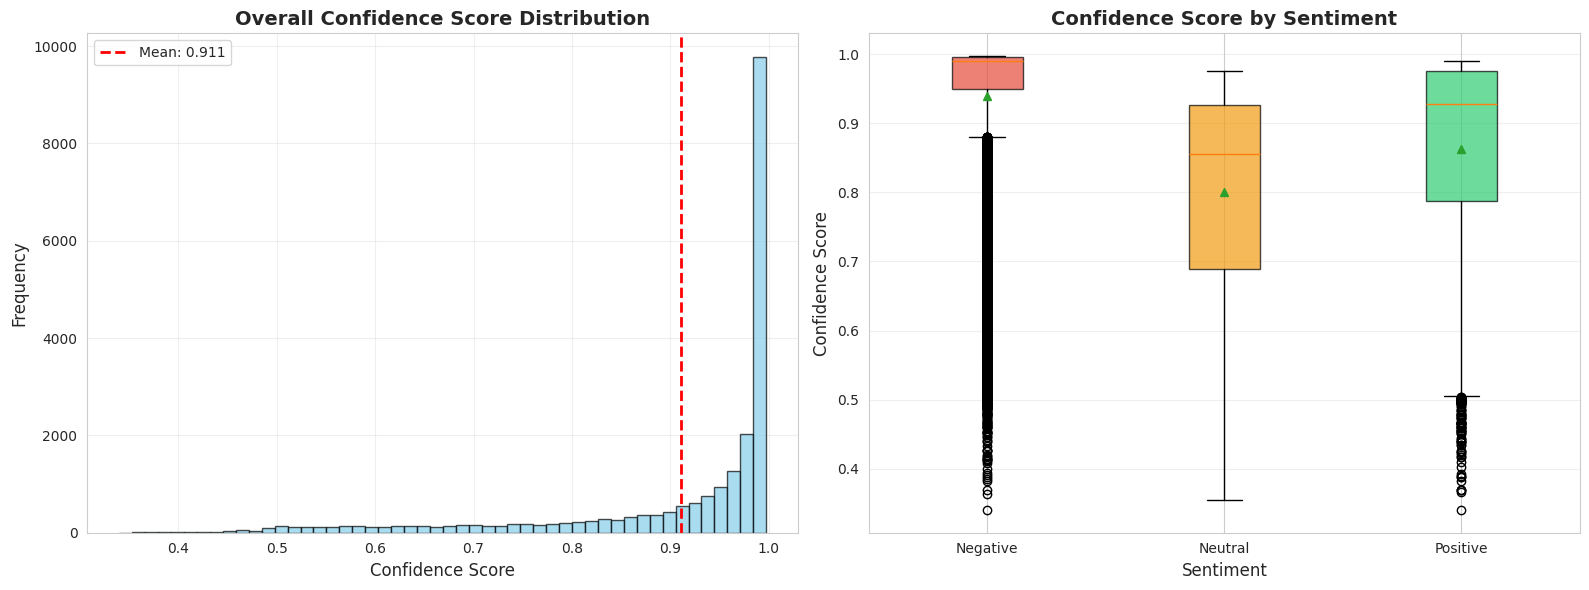


Confidence Score Statistics:
Overall Mean: 0.9107
Overall Median: 0.9775
Overall Std: 0.1322

By Sentiment:
Negative: Mean=0.9397, Median=0.9899, Std=0.1107
Neutral: Mean=0.8009, Median=0.8557, Std=0.1509
Positive: Mean=0.8621, Median=0.9284, Std=0.1480


In [ ]:
# Confidence score distribution by sentiment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for all confidence scores
axes[0].hist(df['confidence'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Overall Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["confidence"].mean():.3f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by sentiment
sentiment_order = ['Negative', 'Neutral', 'Positive']
box_colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

bp = axes[1].boxplot([df[df['predicted_sentiment'] == sent]['confidence'].values
                       for sent in sentiment_order],
                      labels=sentiment_order,
                      patch_artist=True,
                      showmeans=True)

# Color the boxes
for patch, sentiment in zip(bp['boxes'], sentiment_order):
    patch.set_facecolor(box_colors[sentiment])
    patch.set_alpha(0.7)

axes[1].set_title('Confidence Score by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Confidence Score', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nConfidence Score Statistics:")
print(f"Overall Mean: {df['confidence'].mean():.4f}")
print(f"Overall Median: {df['confidence'].median():.4f}")
print(f"Overall Std: {df['confidence'].std():.4f}")
print("\nBy Sentiment:")
for sentiment in sentiment_order:
    conf = df[df['predicted_sentiment'] == sentiment]['confidence']
    print(f"{sentiment}: Mean={conf.mean():.4f}, Median={conf.median():.4f}, Std={conf.std():.4f}")

### 3. Word Clouds by Sentiment

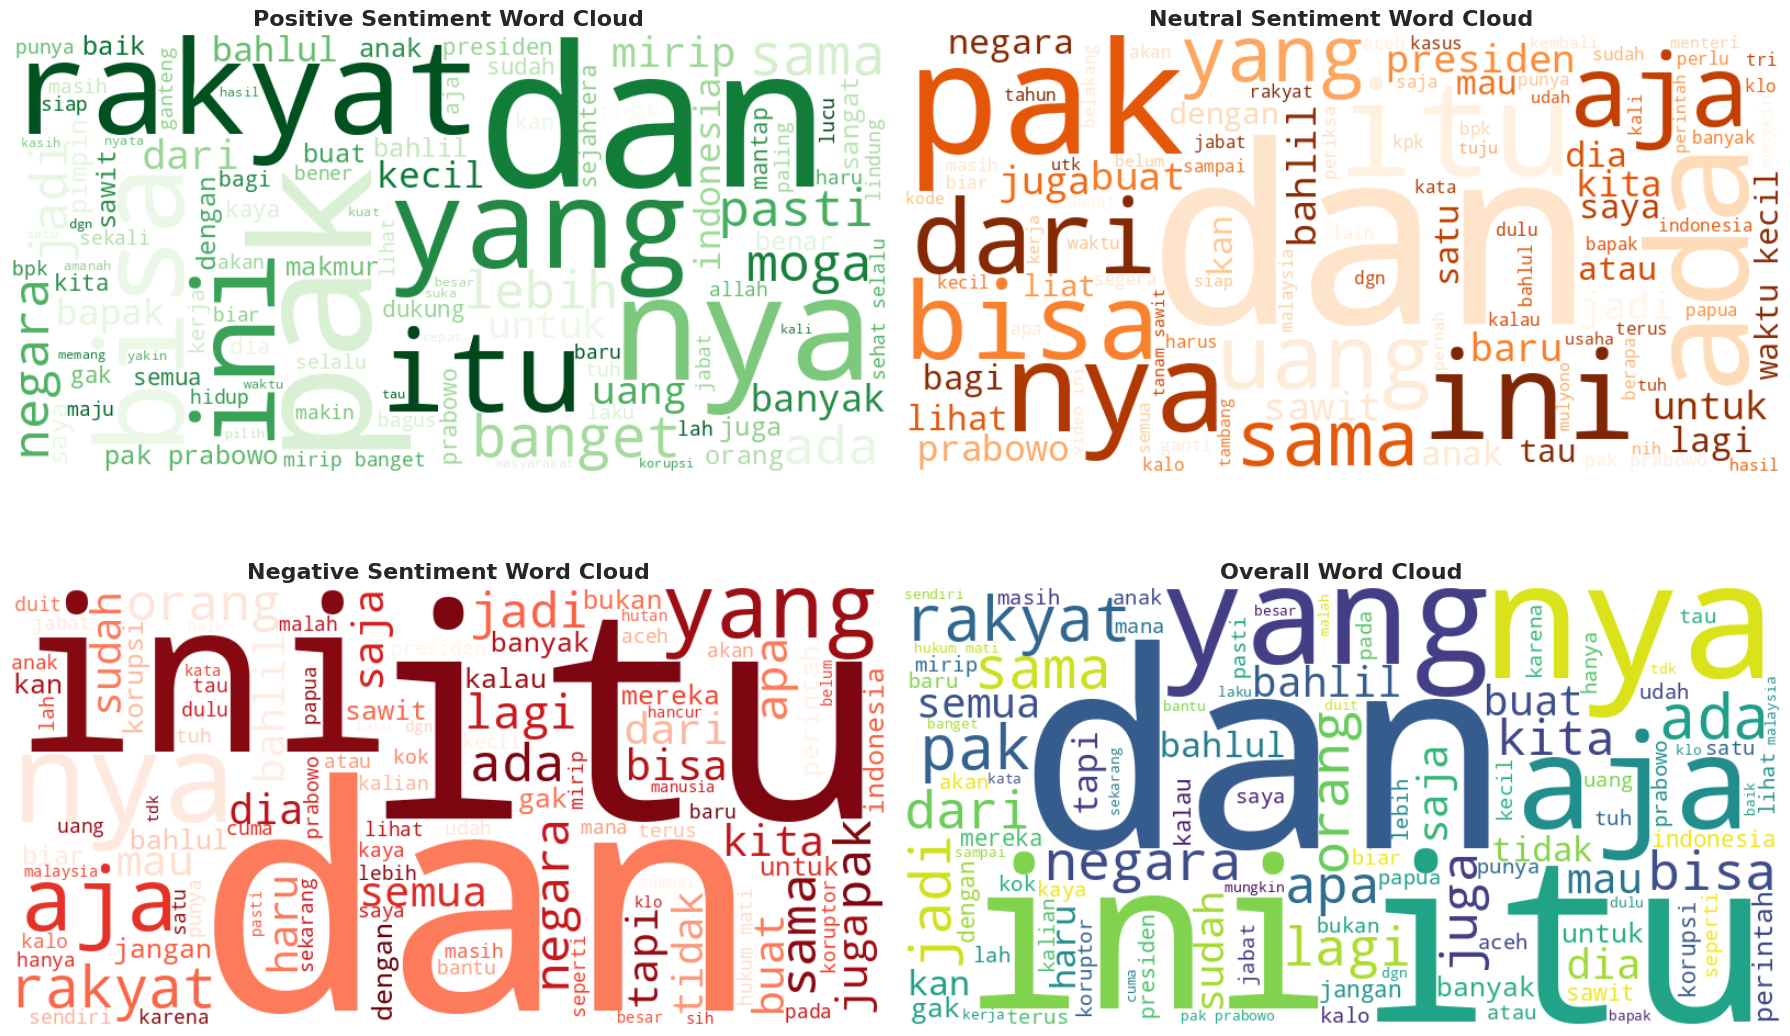

Word clouds generated for each sentiment category!


In [ ]:
# Generate word clouds for each sentiment
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sentiments = ['Positive', 'Neutral', 'Negative']
colors_map = {'Positive': 'Greens', 'Neutral': 'Oranges', 'Negative': 'Reds'}

for idx, sentiment in enumerate(sentiments):
    # Get all comments for this sentiment
    sentiment_comments = df[df['predicted_sentiment'] == sentiment]['cleaned_comments']

    # Combine all comments into one text
    text = ' '.join(sentiment_comments.astype(str))

    # Create word cloud
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         colormap=colors_map[sentiment],
                         max_words=100,
                         relative_scaling=0.5,
                         min_font_size=10).generate(text)

    # Plot
    row = idx // 2
    col = idx % 2
    axes[row, col].imshow(wordcloud, interpolation='bilinear')
    axes[row, col].set_title(f'{sentiment} Sentiment Word Cloud', fontsize=16, fontweight='bold')
    axes[row, col].axis('off')

# Overall word cloud
all_text = ' '.join(df['cleaned_comments'].astype(str))
wordcloud_all = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='viridis',
                          max_words=100,
                          relative_scaling=0.5,
                          min_font_size=10).generate(all_text)

axes[1, 1].imshow(wordcloud_all, interpolation='bilinear')
axes[1, 1].set_title('Overall Word Cloud', fontsize=16, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Word clouds generated for each sentiment category!")

### 4. Top Words by Sentiment

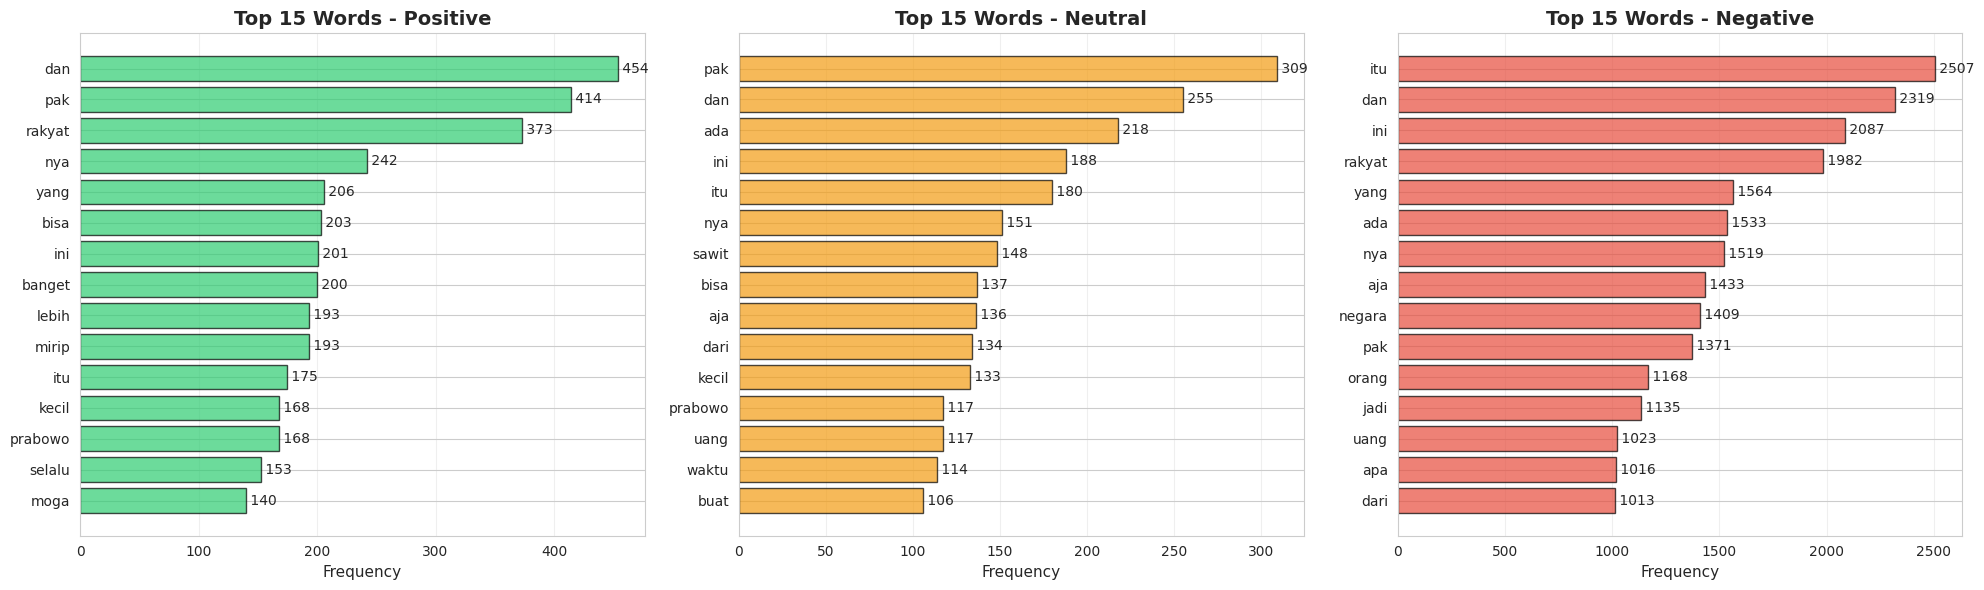

Top words analysis completed!


In [ ]:
# Top 15 most frequent words by sentiment
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sentiments = ['Positive', 'Neutral', 'Negative']
colors_bar = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

for idx, sentiment in enumerate(sentiments):
    # Get all words for this sentiment
    sentiment_comments = df[df['predicted_sentiment'] == sentiment]['cleaned_comments']
    all_words = ' '.join(sentiment_comments.astype(str)).split()

    # Count word frequencies
    word_freq = Counter(all_words)
    top_words = word_freq.most_common(15)

    # Prepare data for plotting
    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    # Plot horizontal bar chart
    axes[idx].barh(words, counts, color=colors_bar[sentiment], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Top 15 Words - {sentiment}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frequency', fontsize=11)
    axes[idx].invert_yaxis()  # Highest at top
    axes[idx].grid(axis='x', alpha=0.3)

    # Add count labels
    for i, count in enumerate(counts):
        axes[idx].text(count, i, f' {count}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Top words analysis completed!")

### 5. Comment Length Analysis

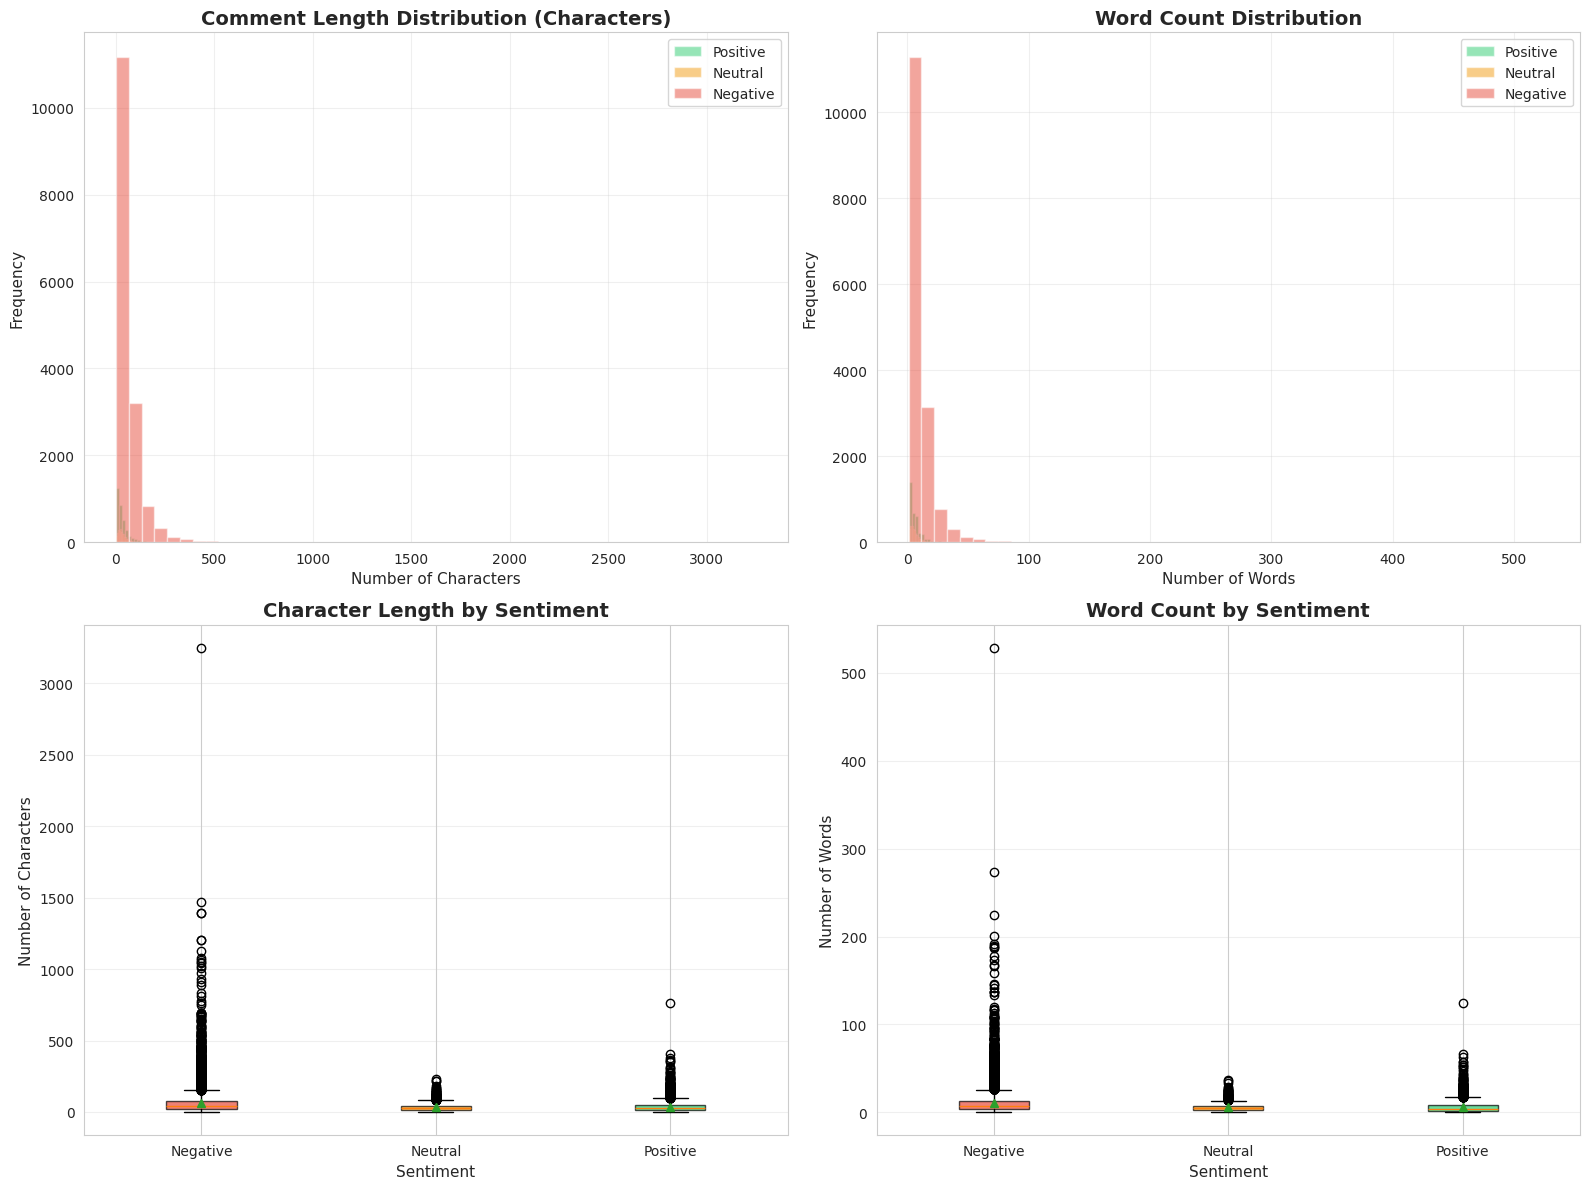


Comment Length Statistics:

By Sentiment (Character Length):
Negative: Mean=63.03, Median=42.00, Max=3247
Neutral: Mean=32.96, Median=28.00, Max=228
Positive: Mean=37.36, Median=25.00, Max=765

By Sentiment (Word Count):
Negative: Mean=10.54, Median=7.00, Max=528
Neutral: Mean=5.65, Median=5.00, Max=37
Positive: Mean=6.17, Median=4.00, Max=124


In [ ]:
# Analyze comment length by sentiment
df['comment_length'] = df['cleaned_comments'].astype(str).apply(len)
df['word_count'] = df['cleaned_comments'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Character length distribution
for sentiment in sentiments:
    data = df[df['predicted_sentiment'] == sentiment]['comment_length']
    axes[0, 0].hist(data, bins=50, alpha=0.5, label=sentiment, color=colors_bar[sentiment])

axes[0, 0].set_title('Comment Length Distribution (Characters)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Characters', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Word count distribution
for sentiment in sentiments:
    data = df[df['predicted_sentiment'] == sentiment]['word_count']
    axes[0, 1].hist(data, bins=50, alpha=0.5, label=sentiment, color=colors_bar[sentiment])

axes[0, 1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Words', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot - Character length by sentiment
bp1 = axes[1, 0].boxplot([df[df['predicted_sentiment'] == sent]['comment_length'].values
                           for sent in sentiment_order],
                          labels=sentiment_order,
                          patch_artist=True,
                          showmeans=True)

for patch, sentiment in zip(bp1['boxes'], sentiment_order):
    patch.set_facecolor(box_colors[sentiment])
    patch.set_alpha(0.7)

axes[1, 0].set_title('Character Length by Sentiment', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment', fontsize=11)
axes[1, 0].set_ylabel('Number of Characters', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot - Word count by sentiment
bp2 = axes[1, 1].boxplot([df[df['predicted_sentiment'] == sent]['word_count'].values
                           for sent in sentiment_order],
                          labels=sentiment_order,
                          patch_artist=True,
                          showmeans=True)

for patch, sentiment in zip(bp2['boxes'], sentiment_order):
    patch.set_facecolor(box_colors[sentiment])
    patch.set_alpha(0.7)

axes[1, 1].set_title('Word Count by Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment', fontsize=11)
axes[1, 1].set_ylabel('Number of Words', fontsize=11)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nComment Length Statistics:")
print("\nBy Sentiment (Character Length):")
for sentiment in sentiment_order:
    length = df[df['predicted_sentiment'] == sentiment]['comment_length']
    print(f"{sentiment}: Mean={length.mean():.2f}, Median={length.median():.2f}, Max={length.max()}")

print("\nBy Sentiment (Word Count):")
for sentiment in sentiment_order:
    words = df[df['predicted_sentiment'] == sentiment]['word_count']
    print(f"{sentiment}: Mean={words.mean():.2f}, Median={words.median():.2f}, Max={words.max()}")

### 6. Sample Comments by Sentiment

In [ ]:
# Display sample comments for each sentiment with high confidence
print("="*80)
print("SAMPLE COMMENTS BY SENTIMENT (High Confidence)")
print("="*80)

for sentiment in sentiment_order:
    print(f"\n{'='*80}")
    print(f"{sentiment.upper()} SENTIMENT - Top 5 High Confidence Examples")
    print(f"{'='*80}")

    # Get high confidence samples
    sentiment_data = df[df['predicted_sentiment'] == sentiment].sort_values('confidence', ascending=False).head(5)

    for idx, (_, row) in enumerate(sentiment_data.iterrows(), 1):
        print(f"\n{idx}. Original: {row['comments'][:150]}...")
        print(f"   Cleaned: {row['cleaned_comments'][:150]}...")
        print(f"   Confidence: {row['confidence']:.4f}")
        print("-" * 80)

SAMPLE COMMENTS BY SENTIMENT (High Confidence)

NEGATIVE SENTIMENT - Top 5 High Confidence Examples

1. Original: Bahlil aja mukanya kek ninja besi ituu apa lagi tambang 😅...
   Cleaned: aja muka kek ninja besi ituu apa lagi tambang...
   Confidence: 0.9973
--------------------------------------------------------------------------------

2. Original: Tunggu apa lagi bapak prabowo liat tuh di belakang bapak colak colek, kaya semacam kode jahat tuh pak.......
   Cleaned: apa lagi bapak prabowo liat tuh belakang bapak colak colek kaya macam kode jahat tuh pak...
   Confidence: 0.9973
--------------------------------------------------------------------------------

3. Original: Kalau rakyat salah di penjara, kalau pejabat salah apa lagi koropsi di lindungi , negara apa ini...
   Cleaned: rakyat salah penjara kalau jabat salah apa lagi koropsi lindung negara apa ini...
   Confidence: 0.9973
--------------------------------------------------------------------------------

4. Original: TERNYA

### 7. Confidence vs Sentiment Heatmap

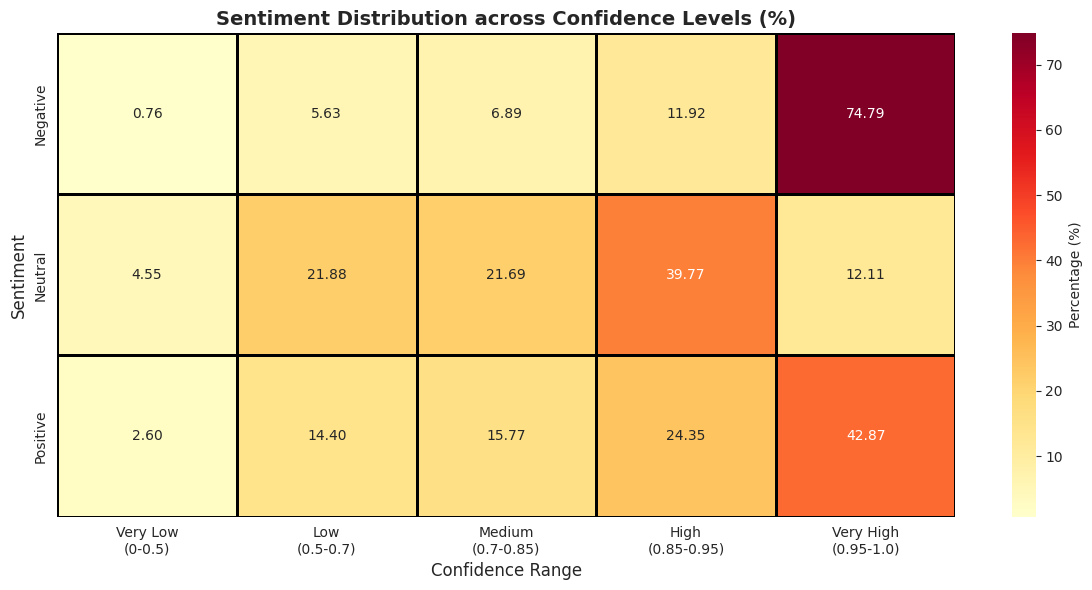


Count of Predictions by Sentiment and Confidence Level:
confidence_bin       Very Low\n(0-0.5)  Low\n(0.5-0.7)  Medium\n(0.7-0.85)  \
predicted_sentiment                                                          
Negative                           121             894                1093   
Neutral                            122             587                 582   
Positive                            89             492                 539   
All                                332            1973                2214   

confidence_bin       High\n(0.85-0.95)  Very High\n(0.95-1.0)    All  
predicted_sentiment                                                   
Negative                          1892                  11869  15869  
Neutral                           1067                    325   2683  
Positive                           832                   1465   3417  
All                               3791                  13659  21969  


In [ ]:
# Create confidence bins and sentiment distribution heatmap
df['confidence_bin'] = pd.cut(df['confidence'],
                                      bins=[0, 0.5, 0.7, 0.85, 0.95, 1.0],
                                      labels=['Very Low\n(0-0.5)', 'Low\n(0.5-0.7)',
                                             'Medium\n(0.7-0.85)', 'High\n(0.85-0.95)',
                                             'Very High\n(0.95-1.0)'])

# Create pivot table for heatmap
heatmap_data = pd.crosstab(df['predicted_sentiment'],
                           df['confidence_bin'],
                           normalize='index') * 100

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=1, linecolor='black')
plt.title('Sentiment Distribution across Confidence Levels (%)', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Range', fontsize=12)
plt.ylabel('Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

# Print count table
print("\nCount of Predictions by Sentiment and Confidence Level:")
count_table = pd.crosstab(df['predicted_sentiment'],
                          df['confidence_bin'],
                          margins=True)
print(count_table)

### 8. Summary Statistics Table


COMPREHENSIVE SENTIMENT ANALYSIS SUMMARY

Total Comments Analyzed: 21,969
Date of Analysis: 2026-01-05 18:39:13

Sentiment  Count Percentage Avg Confidence Avg Word Count Avg Char Length Min Confidence Max Confidence
 Negative  15869     72.23%         0.9397          10.54           63.03         0.3408         0.9973
  Neutral   2683     12.21%         0.8009           5.65           32.96         0.3545         0.9753
 Positive   3417     15.55%         0.8621           6.17           37.36         0.3402         0.9895


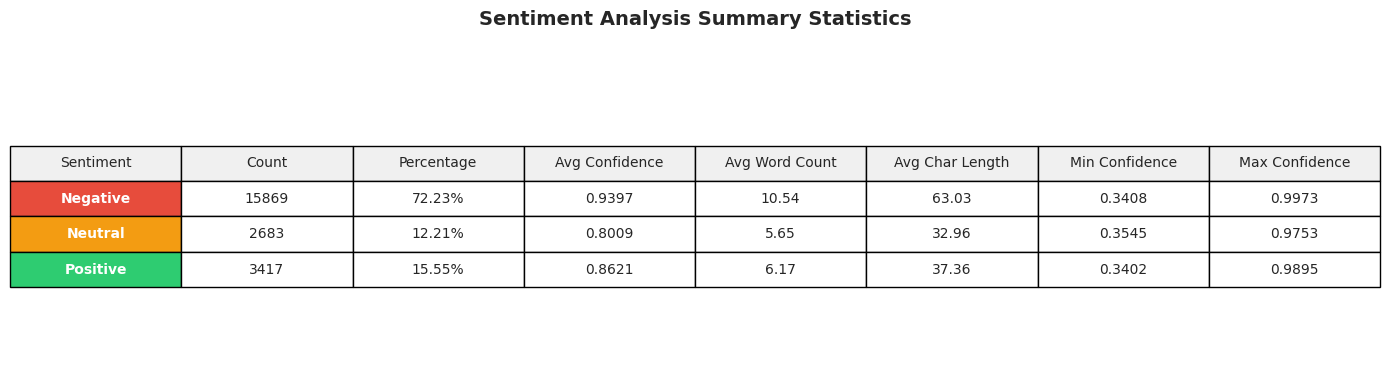

In [ ]:
# Create comprehensive summary statistics table
summary_stats = []

for sentiment in sentiment_order:
    sentiment_data = df[df['predicted_sentiment'] == sentiment]

    stats = {
        'Sentiment': sentiment,
        'Count': len(sentiment_data),
        'Percentage': f"{len(sentiment_data)/len(df)*100:.2f}%",
        'Avg Confidence': f"{sentiment_data['confidence'].mean():.4f}",
        'Avg Word Count': f"{sentiment_data['word_count'].mean():.2f}",
        'Avg Char Length': f"{sentiment_data['comment_length'].mean():.2f}",
        'Min Confidence': f"{sentiment_data['confidence'].min():.4f}",
        'Max Confidence': f"{sentiment_data['confidence'].max():.4f}"
    }
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)

# Display as a styled table
print("\n" + "="*100)
print("COMPREHENSIVE SENTIMENT ANALYSIS SUMMARY")
print("="*100)
print(f"\nTotal Comments Analyzed: {len(df):,}")
print(f"Date of Analysis: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n" + summary_df.to_string(index=False))
print("="*100)

# Create visual table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=summary_df.values,
                colLabels=summary_df.columns,
                cellLoc='center',
                loc='center',
                colColours=['#f0f0f0']*len(summary_df.columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color code sentiment rows
for i in range(len(summary_stats)):
    sentiment = summary_stats[i]['Sentiment']
    color = colors_bar[sentiment]
    table[(i+1, 0)].set_facecolor(color)
    table[(i+1, 0)].set_text_props(weight='bold', color='white')

plt.title('Sentiment Analysis Summary Statistics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()